In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
print("Environment and libraries configured successfully.")

Environment and libraries configured successfully.


In [2]:
df = pd.read_csv("bank-full.csv", sep=';')
print("--- Initial Inspection ---")
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nDataset Schema Info:")
df.info()
print("\nMissing Values Count per Column:")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows Identified: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Cleaned Dataset Dimensions: {df.shape}")

--- Initial Inspection ---
Dataset Dimensions: 45211 rows, 17 columns

Dataset Schema Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Missin

In [3]:
total_contacts = len(df)
engagement_threshold_seconds = 120
df['is_lead'] = (df['duration'] > engagement_threshold_seconds) | (df['y'] == 'yes')
leads = df['is_lead'].sum()
customers = len(df[df['y'] == 'yes'])
traffic_to_lead = (leads / total_contacts) * 100
lead_to_customer = (customers / leads) * 100
overall_conversion = (customers / total_contacts) * 100
drop_contact_to_lead = ((total_contacts - leads) / total_contacts) * 100
drop_lead_to_customer = ((leads - customers) / leads) * 100

summary = pd.DataFrame({
    'Funnel Metric Stage': [
        '1. Total Target Contacts',
        '2. Engaged Leads',
        '3. Converted Customers',
        'Traffic → Lead Conversion Rate',
        'Lead → Customer Conversion Rate',
        'Overall Funnel Conversion Rate'
    ],
    'Value Performance': [
        total_contacts,
        leads,
        customers,
        f'{traffic_to_lead:.2f}%',
        f'{lead_to_customer:.2f}%',
        f'{overall_conversion:.2f}%'
    ]
})

print("--- PIPELINE METRICS GENERATED ---")
summary

--- PIPELINE METRICS GENERATED ---


,Funnel Metric Stage,Value Performance
0,1. Total Target Contacts,45211
1,2. Engaged Leads,31378
2,3. Converted Customers,5289
3,Traffic → Lead Conversion Rate,69.40%
4,Lead → Customer Conversion Rate,16.86%
5,Overall Funnel Conversion Rate,11.70%


Funnel volume and drop-off charts exported successfully.


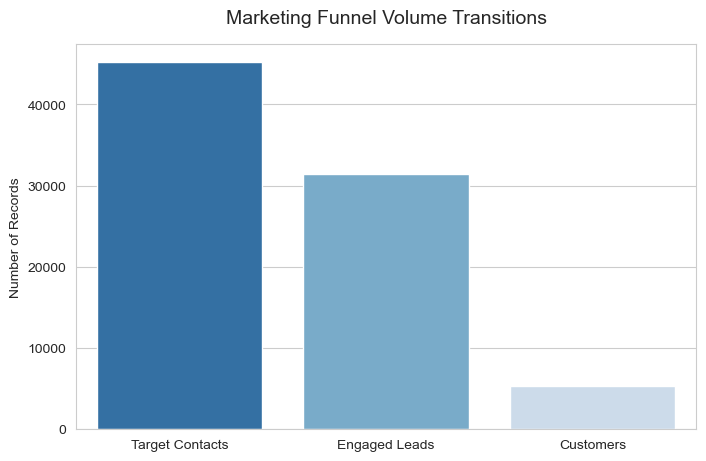

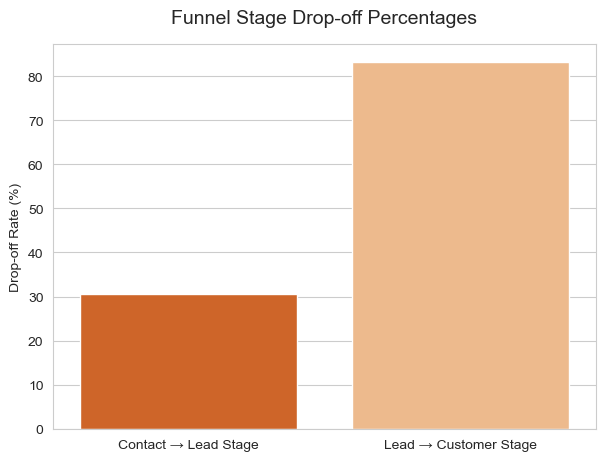

In [4]:
fig1, ax1 = plt.subplots(figsize=(8, 5))
stages = ['Target Contacts', 'Engaged Leads', 'Customers']
volumes = [total_contacts, leads, customers]

sns.barplot(x=stages, y=volumes, ax=ax1, palette='Blues_r')
ax1.set_title("Marketing Funnel Volume Transitions", fontsize=14, pad=15)
ax1.set_ylabel("Number of Records")
fig1.savefig("funnel_volume_analysis.png", bbox_inches='tight')
fig2, ax2 = plt.subplots(figsize=(7, 5))
dropoff_stages = ['Contact → Lead Stage', 'Lead → Customer Stage']
dropoff_rates = [drop_contact_to_lead, drop_lead_to_customer]

sns.barplot(x=dropoff_stages, y=dropoff_rates, ax=ax2, palette='Oranges_r')
ax2.set_title("Funnel Stage Drop-off Percentages", fontsize=14, pad=15)
ax2.set_ylabel("Drop-off Rate (%)")
fig2.savefig("funnel_dropoff_rates.png", bbox_inches='tight')

print("Funnel volume and drop-off charts exported successfully.")

Channel and calendar performance graphs exported successfully.


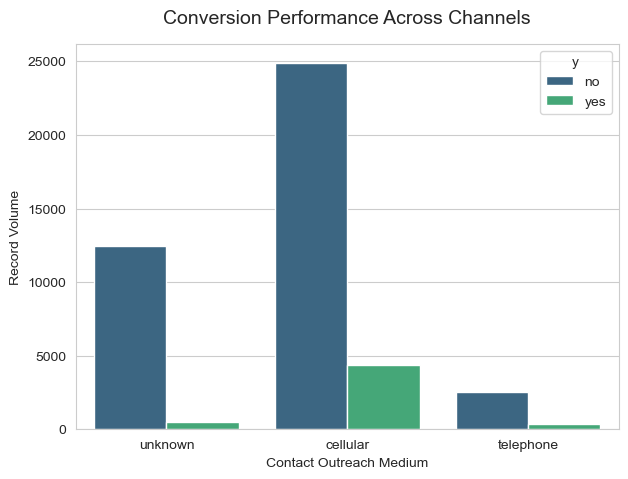

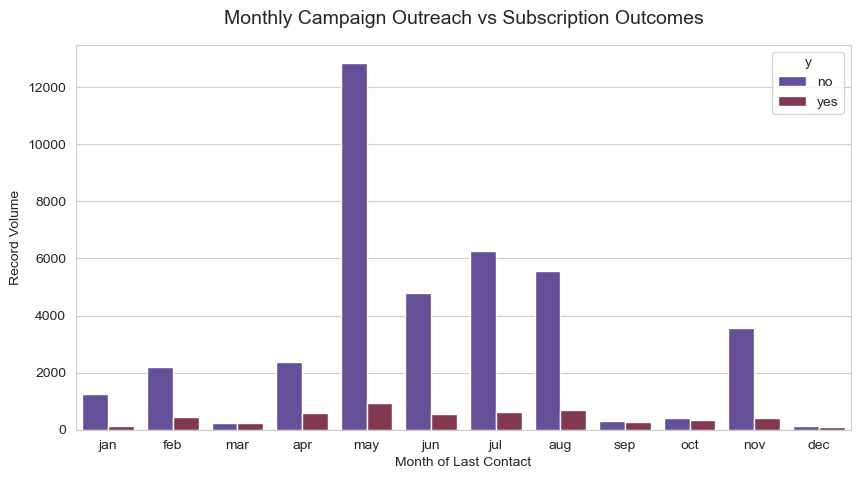

In [5]:
fig3, ax3 = plt.subplots(figsize=(7, 5))
sns.countplot(x='contact', hue='y', data=df, ax=ax3, palette='viridis')
ax3.set_title("Conversion Performance Across Channels", fontsize=14, pad=15)
ax3.set_xlabel("Contact Outreach Medium")
ax3.set_ylabel("Record Volume")
fig3.savefig("channel_conversion_performance.png", bbox_inches='tight')

fig4, ax4 = plt.subplots(figsize=(10, 5))
calendar_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
sns.countplot(x='month', hue='y', data=df, ax=ax4, order=calendar_order, palette='twilight')
ax4.set_title("Monthly Campaign Outreach vs Subscription Outcomes", fontsize=14, pad=15)
ax4.set_xlabel("Month of Last Contact")
ax4.set_ylabel("Record Volume")
fig4.savefig("monthly_conversion_trends.png", bbox_inches='tight')

print("Channel and calendar performance graphs exported successfully.")

Outreach frequency patterns and legacy tracking plots exported successfully.


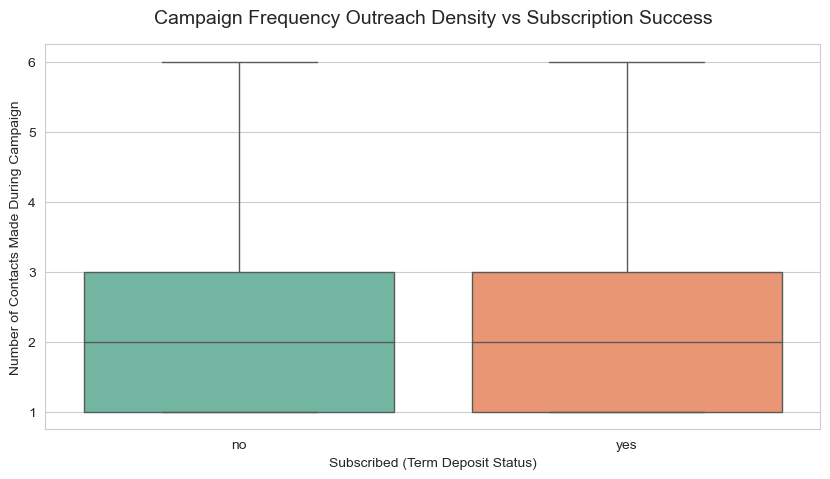

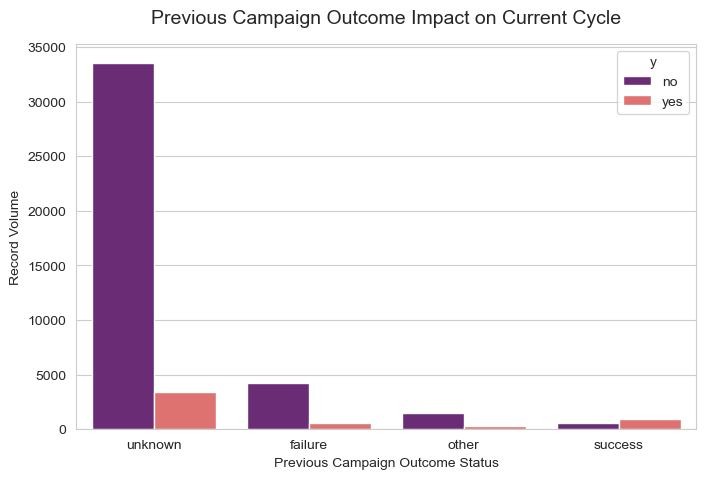

In [6]:
fig5, ax5 = plt.subplots(figsize=(10, 5))
sns.boxplot(x='y', y='campaign', data=df, ax=ax5, showfliers=False, palette='Set2')
ax5.set_title("Campaign Frequency Outreach Density vs Subscription Success", fontsize=14, pad=15)
ax5.set_xlabel("Subscribed (Term Deposit Status)")
ax5.set_ylabel("Number of Contacts Made During Campaign")
fig5.savefig("campaign_frequency_limits.png", bbox_inches='tight')
fig6, ax6 = plt.subplots(figsize=(8, 5))
sns.countplot(x='poutcome', hue='y', data=df, ax=ax6, palette='magma')
ax6.set_title("Previous Campaign Outcome Impact on Current Cycle", fontsize=14, pad=15)
ax6.set_xlabel("Previous Campaign Outcome Status")
ax6.set_ylabel("Record Volume")
fig6.savefig("previous_campaign_impact.png", bbox_inches='tight')

print("Outreach frequency patterns and legacy tracking plots exported successfully.")

Demographic distribution and sector split profiles exported successfully.


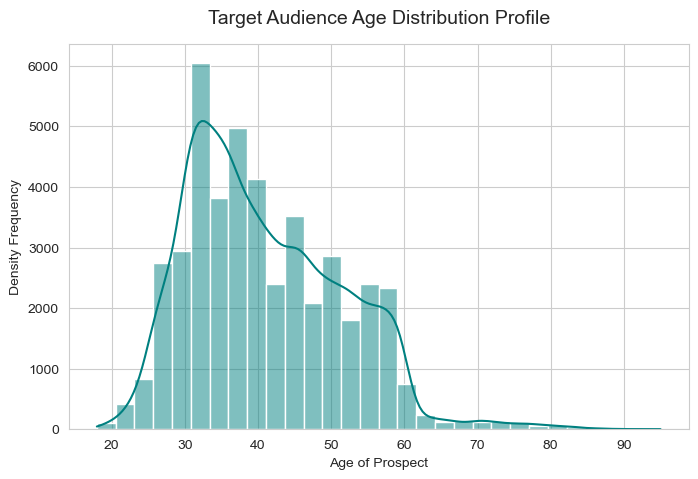

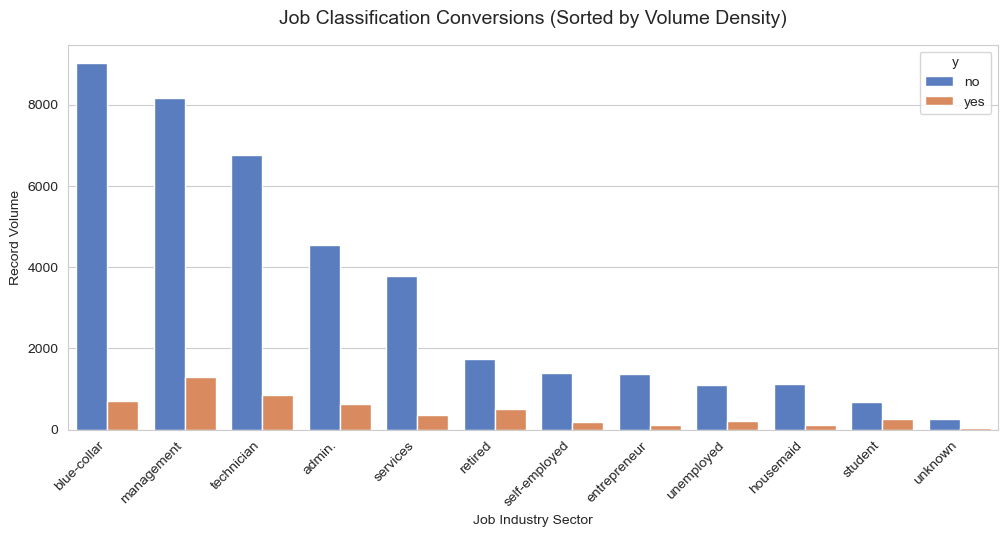

In [7]:
fig7, ax7 = plt.subplots(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True, ax=ax7, color='teal')
ax7.set_title("Target Audience Age Distribution Profile", fontsize=14, pad=15)
ax7.set_xlabel("Age of Prospect")
ax7.set_ylabel("Density Frequency")
fig7.savefig("demographic_age_distribution.png", bbox_inches='tight')
fig8, ax8 = plt.subplots(figsize=(12, 5))
job_frequency_index = df['job'].value_counts().index

sns.countplot(x='job', hue='y', data=df, ax=ax8, order=job_frequency_index, palette='muted')
ax8.set_title("Job Classification Conversions (Sorted by Volume Density)", fontsize=14, pad=15)
ax8.set_xlabel("Job Industry Sector")
ax8.set_ylabel("Record Volume")
plt.xticks(rotation=45, ha='right')
fig8.savefig("job_sector_conversions.png", bbox_inches='tight')

print("Demographic distribution and sector split profiles exported successfully.")

Correlation matrix execution completed.


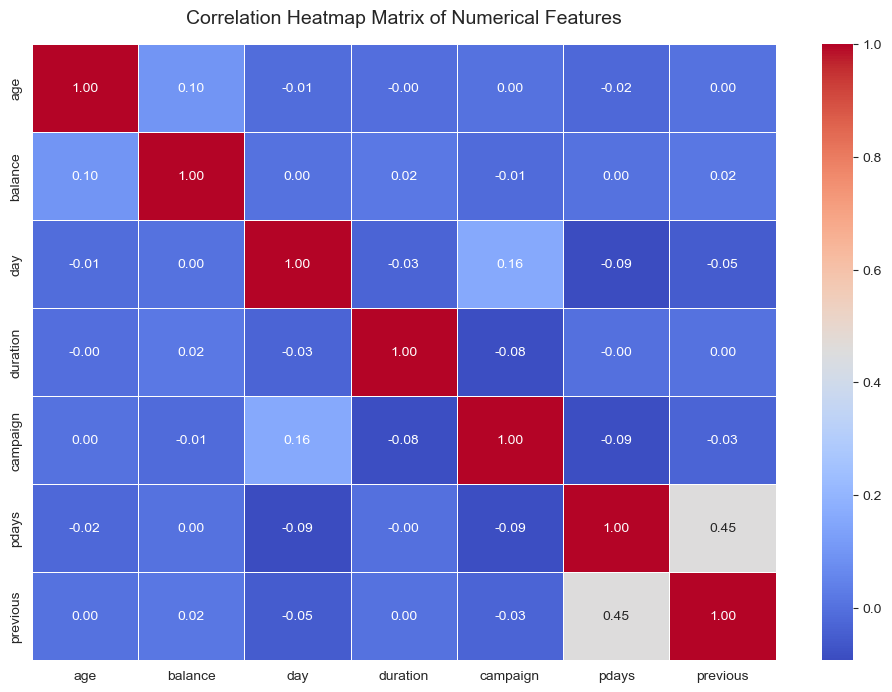

In [8]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

fig9, ax9 = plt.subplots(figsize=(12, 8))
sns.heatmap(numeric_df.corr(method='pearson', numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax9)
ax9.set_title("Correlation Heatmap Matrix of Numerical Features", fontsize=14, pad=15)
fig9.savefig("correlation_heatmap_matrix.png", bbox_inches='tight')

print("Correlation matrix execution completed.")

In [9]:
print("=" * 60)
print("             KEY BUSINESS METRIC DEEP-DIVE")
print("=" * 60)
print(f"1. Early-Stage Attrition: {drop_contact_to_lead:.2f}% of initialized contacts break down before completing {engagement_threshold_seconds}s.")
print(f"2. Core Lead Closing Power: Once qualified as an engaged lead, {lead_to_customer:.2f}% resolve into buyers.")
print("3. Contact Channel Edge: Cellular touchpoints fundamentally outperform standard telephone operations.")
print("4. Call Frequency Cap: Outreach yield hits an operational floor past 3 attempts per campaign cycle.")

print("\n" + "=" * 60)
print("             ACTIONABLE STRATEGIC RECOMMENDATIONS")
print("=" * 60)
recommendations = [
    "Reframe script hooks within the first 45 seconds to secure user engagement past the lead-qualification threshold.",
    "Implement programmatic dialer filters capping outbound efforts to a maximum of 3 unique calls per client.",
    "Prioritize target list routing toward legacy successes, student groups, and asset holders lacking housing loans.",
    "Shift asset allocation and variable budgets away from traditional landline networks to cellular targeting structures."
]

for ranking, tactic in enumerate(recommendations, 1):
    print(f"{ranking}. {tactic}")
print("=" * 60)

             KEY BUSINESS METRIC DEEP-DIVE
1. Early-Stage Attrition: 30.60% of initialized contacts break down before completing 120s.
2. Core Lead Closing Power: Once qualified as an engaged lead, 16.86% resolve into buyers.
3. Contact Channel Edge: Cellular touchpoints fundamentally outperform standard telephone operations.
4. Call Frequency Cap: Outreach yield hits an operational floor past 3 attempts per campaign cycle.

             ACTIONABLE STRATEGIC RECOMMENDATIONS
1. Reframe script hooks within the first 45 seconds to secure user engagement past the lead-qualification threshold.
2. Implement programmatic dialer filters capping outbound efforts to a maximum of 3 unique calls per client.
3. Prioritize target list routing toward legacy successes, student groups, and asset holders lacking housing loans.
4. Shift asset allocation and variable budgets away from traditional landline networks to cellular targeting structures.
